# Assignment 3

In [3]:
import numpy as np
import sympy as sp
import scipy as sc
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

### 1. Introduction

In this document, we study a single pendulum by comparing theoretical predictions to real world data. 

The angle $\theta$ at which a pendulum hangs is governed by the following ODE:
$$
\ddot{\theta} + 2 \gamma \dot{\theta} + \omega^2 \sin(\theta) = 0
$$
where $\gamma \geq 0$ is a "damping coefficient" (how much friction slows the pendulum down) and $\omega > 0$ is the natural frequency of the pendulum. $\omega$ is related to the length of the pendulum $\ell$ and the acceleration incurred on it by gravity: $\omega = \sqrt{g/\ell}$.

The above equation has no closed-form expression, so we often consider it only when $\theta$ is small. In this case, we can apply the approximation $\sin(\theta) \approx \theta$ to simply the equation to $\ddot{\theta} + 2 \gamma \dot{\theta} + \omega^2 \theta = 0$. There is indeed a closed-form expression to this linearised model, as we are now working with a second-order ODE with constant coefficients. 

$$
\theta(t) = \theta_0(t)c(t) + \left ( \frac{\eta_0 + \gamma \theta_0}{\omega_d} \right )s(t)
$$
Is that solution when we are considering the "underdamped" condition ($\gamma < \omega$) and initial conditions $\theta(0) = \theta_0$ and $\dot{\theta}(0) = \eta_0$. The functions $c(t)$, $s(t)$ and constant $\omega_d$ are defined as follows:

$$
\begin{align}
c(t) &= e^{-\gamma t}\cos{(\omega_d t)} \\
s(t) &= e^{- \gamma t}\sin{(\omega_d t)} \\
\omega_d &= \sqrt{\omega^2 - \gamma^2}
\end{align}
$$

$\omega_d$ is the *damped natural frequency*.

### 2. Verifying the exact solution

#### 2.1: Checking the mathematics

To verify that the claims in the introduction are true, see the below python code.

First, we set up our symbolic variables and define $c$, $s$ and $\theta$ in terms of them. We then use `sympy` to find the first and second derivatives of $\theta$ with respect to time. Finally we construct the ODE using $\theta$ and it's derivatives. 

We then run the following checks:
1. At time $t = 0$ we expect our solution to take the value $\theta_0$. To do this we use `.subs` to substitute the value $0$ for $t$, and then `.simplify` to symbolically check we have $\theta_0$. 
2. Similarly we expect $\dot{\theta}$ to produce $\eta_0$ when we sub $t=0$. 
3. We check that $\theta$ and it's derivatives subbed into the ODE simplifies to $0$, in other words, satisfy the differential equation.

In [10]:
# Setup some symbols
t, gamma, omega_d = sp.symbols('t gamma omega_d', real=True)

# Initial condition symbols
theta_0, eta_0 = sp.symbols('theta_0 eta_0', real=True)

# Define c(t) and s(t)
c = sp.exp(-gamma*t) * sp.cos(omega_d*t)
s = sp.exp(-gamma*t) * sp.sin(omega_d*t)

# Define theta(t), this is the solution to the ODE
theta = theta_0 * c + ((eta_0 + gamma*theta_0)/omega_d) * s

# Derivatives
theta_dot = sp.diff(theta, t)
theta_ddot = sp.diff(theta_dot, t)

# ODE: theta'' + 2\gamma theta' + (\omega_d^2 + \gamma^2) theta
ode_expr = theta_ddot + 2*gamma*theta_dot + (omega_d**2 + gamma**2)*theta


# ---- Checks ----
# \theta_0 should be what we get at t=0
print("Check 1: theta(0) = theta_0")
print(sp.simplify(theta.subs(t, 0)))

# We expect \eta_0 as the initial angular velocity
print("\nCheck 2: theta'(0) = eta_0")
print(sp.simplify(theta_dot.subs(t, 0)))

# ODE with theta and it's derivatives should simplify to 0,
# which means theta solves the ODE.
print("\nCheck 3: ODE satisfied (should be 0)")
print(sp.simplify(ode_expr))

Check 1: theta(0) = theta_0
theta_0

Check 2: theta'(0) = eta_0
eta_0

Check 3: ODE satisfied (should be 0)
0


#### 2.2: Plotting the solution

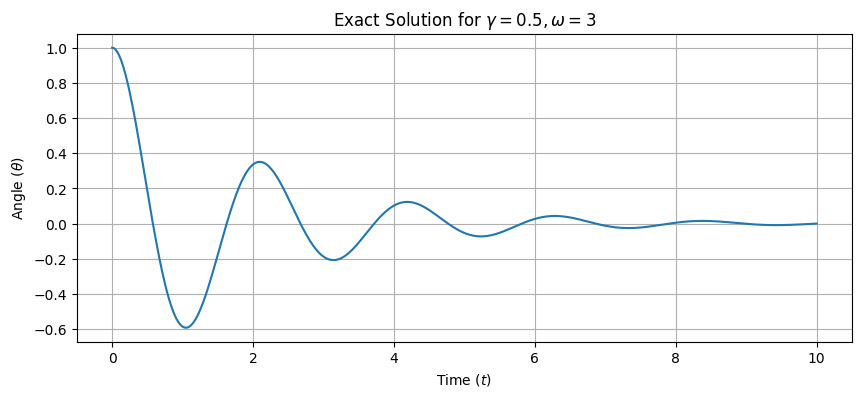

In [22]:
def cos_exp(ts, gamma, omega_d):
    return np.exp(-gamma*ts) * np.cos(omega_d*ts)

def sin_exp(ts, gamma, omega_d):
    return np.exp(-gamma*ts) * np.sin(omega_d*ts)


def plot_exact(gamma, omega, theta0, eta0, t_max=10, num_points=1000):
    """
    Plot the exact solution for given parameters.

    :param gamma: Damping coefficient
    :param omega: Natural frequency
    :param theta0: Initial angle
    :param eta0: Initial angular velocity
    :param t_max: Maximum time to plot
    :param num_points: Number of points in the plot
    """
    ts = np.linspace(0, t_max, num_points)
    cs = cos_exp(ts, gamma, omega)
    ss = sin_exp(ts, gamma, omega)
    thetas = theta0 * cs + ((eta0 + gamma*theta0)/omega) * ss
    
    plt.figure(figsize=(10, 4))
    plt.plot(ts, thetas)
    plt.title(f'Exact Solution for $\\gamma={gamma}, \\omega={omega}$')
    plt.xlabel('Time ($t$)')
    plt.ylabel('Angle ($\\theta$)')
    plt.grid()
    plt.show()


plot_exact(gamma=0.5, omega=3, theta0=1, eta0=0)

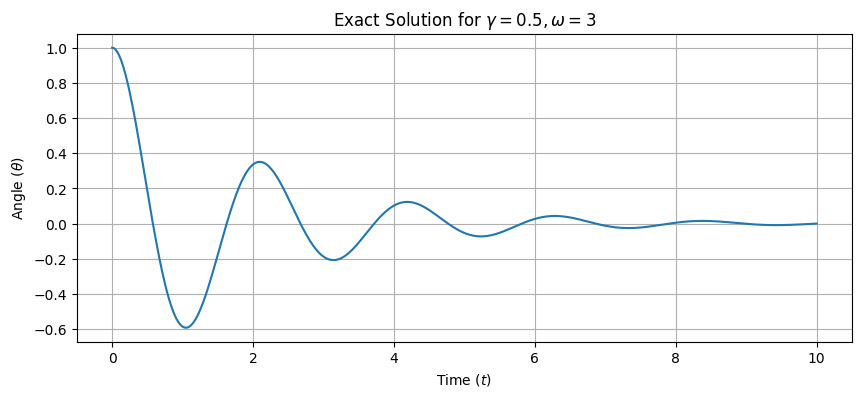

Above is the plot of $\theta$ against time with parameters $\gamma=0.5$, $\omega=0.3$, $\theta_0 = 1$ and $\eta_0 = 0$. It shows a clear damped oscillating pattern. "oscillating" here describes the solution moving up and down in a regular fashion, like a wave, and the "damped" part describes the magnitude of this wave gradually decreasing. 




### Part 3: Fitting a linear model

#### 3.1: Plotting the data

Head of 'pendulum1.csv':
   Unnamed: 0     t     theta
0           0  3.00  0.445173
1           1  3.04  0.275452
2           2  3.08  0.206092
3           3  3.12  0.284490
4           4  3.16  0.382913

Column names:
Unnamed: 0, t, theta

Data types:
Unnamed: 0      int64
t             float64
theta         float64
dtype: object


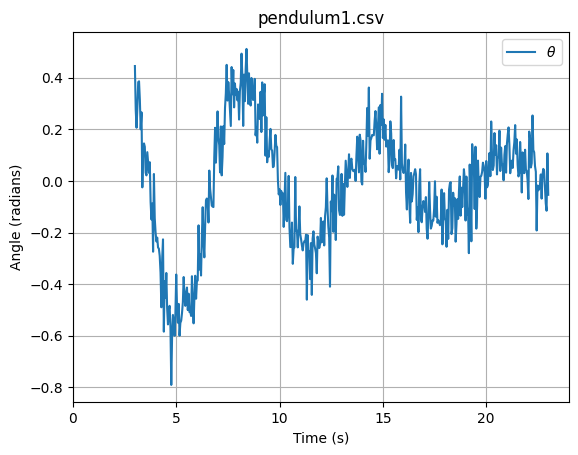

In [43]:
# Read the CSV file into a DataFrame
df = pd.read_csv("pendulum1.csv")

# Inspect the head of the dataframe
print("Head of 'pendulum1.csv':")
print(df.head())

# Print column names and data types
print("\nColumn names:")
print(*list(df.columns), sep=", ")
print("\nData types:")
print(df.dtypes)

# ---- Plotting ----
plt.figure()

# Create plot from columns 1 (time) and 2 (angle) of the dataframe
plt.plot(df.iloc[:, 1], df.iloc[:, 2], label="$\\theta$")

# Force x-axis to start at 0
plt.xlim(left=0)

# Add labels and legend
plt.xlabel("Time (s)")
plt.ylabel("Angle (radians)")
plt.title("pendulum1.csv")
plt.legend()
plt.grid()

plt.show()

Plot of data from `pendulum1.csv` file. We see there is an oscillatory relationship between $\theta$ (angle of the pendulum in radians) and time $t$.  